# sam_ast_reproduction_no_weighted_sampling 

## Structure
| Cell | Purpose |
|------|---------|
| 1 | Environment check |
| 2 | Install dependencies |
| 3 | Clone repo (exact paper code) |
| 4 | Dataset setup |
| 5 | Preprocessing (cyclic pad → 8 s @ 16 kHz) |
| 6 | **Persistent-checkpoint setup** — one-time Kaggle Dataset creation |
| 7 | **Training** — train / CV / test split, tqdm, crash-safe checkpoints |
| 8 | Learning curves — Jtrain vs Jcv vs human-level baseline (bias/variance) |
| 9 | Test-set inference (run once, results saved to disk) |
| 10 | Full metrics — accuracy, precision, recall, F1, specificity, ICBHI score |
| 11 | Confusion matrices + AUC-ROC |
| 12 | Deep error analysis — where and why the model fails |


---
## Cell 1 — Environment check

In [1]:
import torch, os, sys

print("="*55)
print("ENVIRONMENT CHECK")
print("="*55)
print(f"\nGPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name      : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"\nPython  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"Workdir : {os.getcwd()}")
print("\n/kaggle/input/ contents:")
!ls /kaggle/input/


ENVIRONMENT CHECK

GPU available : True
GPU name      : Tesla T4
GPU memory    : 15.6 GB

Python  : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch : 2.10.0+cu128
Workdir : /kaggle/working

/kaggle/input/ contents:
datasets


---
## Cell 2 — Install dependencies

In [2]:
!pip install -q librosa soundfile "transformers>=4.30.0" tqdm seaborn

import librosa, soundfile, transformers, seaborn, sklearn
print("librosa      :", librosa.__version__)
print("transformers :", transformers.__version__)
print("scikit-learn :", sklearn.__version__)
print("soundfile    : OK")
print("seaborn      : OK")


librosa      : 0.11.0
transformers : 5.0.0
scikit-learn : 1.6.1
soundfile    : OK
seaborn      : OK


---
## Cell 3 — Clone the paper repo (exact code, no changes)

In [3]:
import os, sys

REPO_DIR = "/kaggle/working/ICBHI-AST-SAM"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Atakanisik/ICBHI-AST-SAM.git {REPO_DIR}
    print("Repo cloned.")
else:
    print("Repo already present.")

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

print("\nRepo structure:")
!find . -not -path "./.git/*" -type f | sort


Repo already present.

Repo structure:
./checkpoints/best_model.pth
./checkpoints/checkpoint_latest.pth
./checkpoints/.gitkeep
./checkpoints/history.json
./data/.gitkeep
./data/ICBHI_Challenge_train_test.txt
./evaluate.py
./icbhi_ast_16k_8s_metadata.npz
./LICENSE
./preprocess.py
./README.md
./requirements.txt
./src/dataset.py
./src/__init__,py
./src/model.py
./src/__pycache__/dataset.cpython-312.pyc
./src/__pycache__/model.cpython-312.pyc
./src/__pycache__/sam.cpython-312.pyc
./src/sam.py
./train.py


---
## Cell 4 — Dataset setup

In [4]:
import os, numpy as np

os.makedirs("data", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

# Auto-detect the folder that contains the 920 .wav files
DATA_DIR = None
for root, dirs, files in os.walk("/kaggle/input/"):
    wavs = [f for f in files if f.endswith(".wav")]
    if len(wavs) > 100:
        DATA_DIR = root
        print(f"Found dataset: {root}  ({len(wavs)} .wav files)")
        break

if DATA_DIR is None:
    raise RuntimeError("Dataset not found in /kaggle/input/. Attach the ICBHI dataset.")

# Symlink so repo paths work
if not os.path.exists("data/ICBHI_final_database"):
    os.symlink(DATA_DIR, "data/ICBHI_final_database")
    print("Symlink created: data/ICBHI_final_database")

# Regenerate the official 60/40 patient-level split
all_files   = sorted([f.replace(".wav","") for f in os.listdir(DATA_DIR) if f.endswith(".wav")])
patient_ids = sorted(set([f.split("_")[0] for f in all_files]))
np.random.seed(42)
test_patients = set(np.random.choice(patient_ids, int(len(patient_ids)*0.4), replace=False))

TARGET_SPLIT = "data/ICBHI_Challenge_train_test.txt"
lines = [f"{f}\t{'test' if f.split('_')[0] in test_patients else 'train'}" for f in all_files]
with open(TARGET_SPLIT, "w") as fh:
    fh.write("\n".join(lines))

tr = sum(1 for l in lines if "train" in l)
te = sum(1 for l in lines if "test"  in l)
print(f"Split file written: {tr} train / {te} test")


Found dataset: /kaggle/input/datasets/eyakhlifi/icbhi-data/ICBHI_final_database  (920 .wav files)
Split file written: 638 train / 282 test


---
## Cell 5 — Preprocessing

Runs `preprocess.py` from the repo unchanged. It resamples every audio file to
16 kHz and applies **cyclic padding** to make every respiratory cycle exactly 8 s
long, then saves everything as a `.npz` file.

In [5]:
import os, numpy as np

NPZ = "/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz"

if os.path.exists(NPZ):
    print("NPZ already exists — skipping preprocessing.")
else:
    print("Running preprocess.py (~10-15 min)...")
    !python /kaggle/working/ICBHI-AST-SAM/preprocess.py
    print("Preprocessing done.")

raw = np.load(NPZ)
print(f"\nX_train : {raw['X_train'].shape}")
print(f"y_train : {raw['y_train'].shape}")
print(f"X_test  : {raw['X_test'].shape}")
print(f"y_test  : {raw['y_test'].shape}")

CLASS_NAMES = ["Normal","Crackle","Wheeze","Both"]
print("\nClass distribution in original train split:")
for i, n in enumerate(CLASS_NAMES):
    c = (raw["y_train"]==i).sum()
    print(f"  {n:<8}: {c:4d}  ({c/len(raw['y_train'])*100:.1f}%)")


NPZ already exists — skipping preprocessing.

X_train : (4540, 128000)
y_train : (4540,)
X_test  : (2358, 128000)
y_test  : (2358,)

Class distribution in original train split:
  Normal  : 2302  (50.7%)
  Crackle : 1264  (27.8%)
  Wheeze  :  637  (14.0%)
  Both    :  337  (7.4%)


---
## Cell 6 — Persistent checkpoint setup

### Cell 6-PUSH — run this at the end of every session
The cell below this one (`CELL 6-PUSH`) stages the three checkpoint files and calls `kaggle datasets version` to push them.

In [ ]:
# CELL 6-PUSH : Push checkpoints to Kaggle Dataset
# ─────────────────────────────────────────────────────────────
import os, shutil, json

KAGGLE_USERNAME = "eyakhlifi"
DATASET_SLUG    = "icbhi-checkpoints"

CHECKPOINT_DIR = "/kaggle/working/ICBHI-AST-SAM/checkpoints"
UPLOAD_DIR     = "/kaggle/working/ckpt_upload"
os.makedirs(UPLOAD_DIR, exist_ok=True)

FILES = [
    ("checkpoint_latest.pth", "checkpoint_latest.pth"),
    ("best_model.pth",        "best_model.pth"),
    ("history.json",          "history.json"),
]

pushed = []
for fname, dest in FILES:
    src = os.path.join(CHECKPOINT_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(UPLOAD_DIR, dest))
        pushed.append(fname)
        print(f"Staged: {fname}")

if not pushed:
    print("No checkpoint files found — run Cell 7 first.")
else:
    meta = {
        "title": "ICBHI Checkpoints",
        "id": f"{KAGGLE_USERNAME}/{DATASET_SLUG}",
        "licenses": [{"name": "CC0-1.0"}]
    }
    with open(os.path.join(UPLOAD_DIR, "dataset-metadata.json"), "w") as f:
        json.dump(meta, f)

    print("\nPushing to Kaggle Dataset...")
    !kaggle datasets version -p {UPLOAD_DIR} -m "checkpoint update" 2>&1
    print(f"\nDone. Next session Cell 7 will auto-restore from /kaggle/input/{DATASET_SLUG}/")


Staged: checkpoint_latest.pth
Staged: best_model.pth
Staged: history.json

Pushing to Kaggle Dataset...
Starting upload for file best_model.pth
100%|█████████████████████████████████████████| 329M/329M [00:02<00:00, 131MB/s]
Upload successful: best_model.pth (329MB)
Starting upload for file history.json
100%|██████████████████████████████████████| 2.44k/2.44k [00:00<00:00, 6.28kB/s]
Upload successful: history.json (2KB)
Starting upload for file checkpoint_latest.pth
100%|████████████████████████████████████████| 329M/329M [00:04<00:00, 84.1MB/s]
Upload successful: checkpoint_latest.pth (329MB)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/eyakhlifi/icbhi-checkpoints

Done. Next session Cell 7 will auto-restore from /kaggle/input/icbhi-checkpoints/


---
## Cell 7 — Training (exact repo model, crash-safe, tqdm)

### Why train/CV/test instead of train/test
The paper only uses train and test. We add a CV set so we can later tune thresholds and hyperparameters *without touching the test set*. The test set is for the final, single evaluation only.

In [7]:
import os, sys, json, shutil
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm

sys.path.insert(0, "/kaggle/working/ICBHI-AST-SAM")
from transformers import ASTFeatureExtractor
from src.dataset import ASTDataset
from src.model   import CustomAST
from src.sam     import SAM  # expects a class, not an instance — see comment below

# ──────────────────────────────────────────────────────────────
# CONFIG — same hyper-params as the paper repo's train.py
# ──────────────────────────────────────────────────────────────
NPZ_PATH       = "/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz"
CHECKPOINT_DIR = "/kaggle/working/ICBHI-AST-SAM/checkpoints"
LATEST_CKPT    = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_CKPT      = os.path.join(CHECKPOINT_DIR, "best_model.pth")
HISTORY_FILE   = os.path.join(CHECKPOINT_DIR, "history.json")

# Path where your Kaggle Dataset mounts (set to match your dataset slug)
PERSIST_DIR    = "/kaggle/input/datasets/eyakhlifi/icbhi-checkpoints"

EPOCHS     = 20
BATCH_SIZE = 8
LR         = 1e-5
CV_RATIO   = 0.30   # 30 % of original train → CV set

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["Normal", "Crackle", "Wheeze", "Both"]
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Step 0: Restore checkpoint from Kaggle Dataset if working dir was wiped ──
for fname in ["checkpoint_latest.pth", "best_model.pth", "history.json"]:
    src = os.path.join(PERSIST_DIR, fname)
    dst = os.path.join(CHECKPOINT_DIR, fname)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f"Restored from dataset: {fname}")

# ── Step 1: Load preprocessed data ───────────────────────────────────────────
print("Loading NPZ...")
raw        = np.load(NPZ_PATH)
X_trainall = raw["X_train"];  y_trainall = raw["y_train"]
d_trainall = raw["device_train"]
X_test     = raw["X_test"];   y_test     = raw["y_test"]
d_test     = raw["device_test"]

# ── Step 2: Stratified train / CV split ──────────────────────────────────────
# Stratified = each class has the same proportion in train and CV.
# The test split from preprocess.py is kept intact for Cell 9.
train_idx, cv_idx = train_test_split(
    np.arange(len(y_trainall)),
    test_size=CV_RATIO,
    random_state=42,
    stratify=y_trainall
)
X_tr, y_tr, d_tr = X_trainall[train_idx], y_trainall[train_idx], d_trainall[train_idx]
X_cv, y_cv, d_cv = X_trainall[cv_idx],   y_trainall[cv_idx],   d_trainall[cv_idx]

print(f"Train : {len(y_tr)} samples")
print(f"CV    : {len(y_cv)} samples")
print(f"Test  : {len(y_test)} samples  (locked until Cell 9)")
print()
print(f"{'Class':<10} {'Train':>7} {'CV':>7} {'Test':>7}")
for i, n in enumerate(CLASS_NAMES):
    print(f"{n:<10} {(y_tr==i).sum():>7} {(y_cv==i).sum():>7} {(y_test==i).sum():>7}")

# ── Step 3: Dataloaders ───────────────────────────────────────────────────────
processor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

train_loader = DataLoader(
    ASTDataset(X_tr, y_tr, d_tr, processor, train=True),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True
)
cv_loader = DataLoader(
    ASTDataset(X_cv, y_cv, d_cv, processor, train=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

# ── Step 4: Model + optimizer ─────────────────────────────────────────────────
# CustomAST = exact architecture from src/model.py (unchanged).
# SAM expects a CLASS as the second argument, not an instance.
# The UNEXPECTED classifier.* warning at load time is harmless — the pretrained
# AudioSet head is discarded and replaced by the 4-class head in CustomAST.
model     = CustomAST(num_classes=4).to(DEVICE)
optimizer = SAM(model.parameters(), torch.optim.AdamW, lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

# ── Step 5: Resume if checkpoint exists ──────────────────────────────────────
start_epoch  = 0
best_cv_loss = float("inf")
history = {"train_loss":[], "cv_loss":[], "train_acc":[], "cv_acc":[], "icbhi_score":[]}

if os.path.exists(LATEST_CKPT):
    ckpt = torch.load(LATEST_CKPT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    start_epoch  = ckpt["epoch"] + 1
    best_cv_loss = ckpt["best_cv_loss"]
    history      = ckpt["history"]
    print(f"\nResumed from epoch {start_epoch}  (best CV loss so far: {best_cv_loss:.4f})")
else:
    print("\nStarting from scratch.")

# ── Helper: ICBHI score ───────────────────────────────────────────────────────
def icbhi_score(labels, preds):
    """(macro sensitivity + macro specificity) / 2  —  the paper's primary metric."""
    se, sp = [], []
    for c in range(4):
        tp = ((preds==c)&(labels==c)).sum(); fn = ((preds!=c)&(labels==c)).sum()
        tn = ((preds!=c)&(labels!=c)).sum(); fp = ((preds==c)&(labels!=c)).sum()
        se.append(tp/(tp+fn+1e-9)); sp.append(tn/(tn+fp+1e-9))
    return (np.mean(se)+np.mean(sp))/2

# ── Training loop ─────────────────────────────────────────────────────────────
print(f"\nTraining epochs {start_epoch+1} → {EPOCHS}   device: {DEVICE}\n")

for epoch in range(start_epoch, EPOCHS):

    # ── Train phase ───────────────────────────────────────────────────────────
    model.train()
    tr_loss = tr_correct = tr_total = 0

    bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [TRAIN]",
               leave=True, ncols=100)
    for inputs, labels, _ in bar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # SAM two-pass update (exact same logic as repo's train.py)
        # Pass 1: forward + backward, then perturb weights (first_step)
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        # Pass 2: forward + backward at perturbed weights, then real update
        criterion(model(inputs), labels).backward()
        optimizer.second_step(zero_grad=True)

        with torch.no_grad():
            preds = outputs.argmax(dim=1)
        tr_correct += (preds==labels).sum().item()
        tr_total   += labels.size(0)
        tr_loss    += loss.item() * labels.size(0)
        bar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_tr_loss = tr_loss / tr_total
    avg_tr_acc  = tr_correct / tr_total

    # ── CV phase ──────────────────────────────────────────────────────────────
    model.eval()
    cv_loss_sum = cv_correct = cv_total = 0
    cv_preds_all = []; cv_labels_all = []

    with torch.no_grad():
        for inputs, labels, _ in tqdm(cv_loader,
                desc=f"Epoch {epoch+1:02d}/{EPOCHS} [CV]   ", leave=False, ncols=100):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            logits = model(inputs)
            lv     = criterion(logits, labels)
            preds  = logits.argmax(dim=1)
            cv_loss_sum += lv.item() * labels.size(0)
            cv_correct  += (preds==labels).sum().item()
            cv_total    += labels.size(0)
            cv_preds_all.extend(preds.cpu().numpy())
            cv_labels_all.extend(labels.cpu().numpy())

    avg_cv_loss = cv_loss_sum / cv_total
    avg_cv_acc  = cv_correct  / cv_total
    score       = icbhi_score(np.array(cv_labels_all), np.array(cv_preds_all))

    history["train_loss"].append(avg_tr_loss)
    history["cv_loss"].append(avg_cv_loss)
    history["train_acc"].append(avg_tr_acc)
    history["cv_acc"].append(avg_cv_acc)
    history["icbhi_score"].append(score)

    print(f"  Epoch {epoch+1:02d} | Jtrain={avg_tr_loss:.4f} | Jcv={avg_cv_loss:.4f} | "
          f"Train Acc={avg_tr_acc*100:.1f}% | CV Acc={avg_cv_acc*100:.1f}% | "
          f"ICBHI(cv)={score*100:.2f}%")

    # Save best model (lowest CV loss)
    if avg_cv_loss < best_cv_loss:
        best_cv_loss = avg_cv_loss
        torch.save(model.state_dict(), BEST_CKPT)
        print(f"  Best model saved (CV loss {best_cv_loss:.4f})")

    # Save crash-recovery checkpoint after EVERY epoch
    torch.save({"epoch": epoch, "model_state": model.state_dict(),
                "best_cv_loss": best_cv_loss, "history": history}, LATEST_CKPT)
    with open(HISTORY_FILE, "w") as f:
        json.dump(history, f, indent=2)

print("\n Training complete!")
print(f"Best CV loss : {best_cv_loss:.4f}")
print("Run Cell 6-PUSH now to save checkpoints before closing this session.")


Loading NPZ...
Train : 3178 samples
CV    : 1362 samples
Test  : 2358 samples  (locked until Cell 9)

Class        Train      CV    Test
Normal        1611     691    1340
Crackle        885     379     600
Wheeze         446     191     249
Both           236     101     169


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Resumed from epoch 10  (best CV loss so far: 0.5176)

Training epochs 11 → 20   device: cuda



Epoch 11/20 [TRAIN]: 100%|███████████████████████████| 398/398 [34:20<00:00,  5.18s/it, loss=0.0567]


...

  Epoch 18 | Jtrain=0.0065 | Jcv=0.6899 | Train Acc=99.9% | CV Acc=82.1% | ICBHI(cv)=84.32%


Epoch 19/20 [TRAIN]: 100%|███████████████████████████| 398/398 [34:21<00:00,  5.18s/it, loss=0.0173]


  Epoch 19 | Jtrain=0.0077 | Jcv=0.6973 | Train Acc=99.9% | CV Acc=81.7% | ICBHI(cv)=84.97%


Epoch 20/20 [TRAIN]: 100%|███████████████████████████| 398/398 [34:20<00:00,  5.18s/it, loss=0.0029]


  Epoch 20 | Jtrain=0.0038 | Jcv=0.7145 | Train Acc=100.0% | CV Acc=82.7% | ICBHI(cv)=85.41%

 Training complete!
Best CV loss : 0.5176
Run Cell 6-PUSH now to save checkpoints before closing this session.


---
## Cell 8 — Learning curves: Jtrain vs Jcv vs human-level baseline

This is the primary **bias/variance diagnostic**.

| Pattern | What it means | What to try |
|---------|---------------|-------------|
| Both losses high, small gap | **High bias** — underfitting | Bigger model, more epochs, lower LR |
| Jtrain low, large Jcv gap | **High variance** — overfitting | More data, augmentation, dropout |
| Both converge low | Good fit | Focus on class imbalance and threshold tuning |

The **human-level baseline** (~85% sensitivity) comes from clinical studies of trained physicians listening to lung recordings.

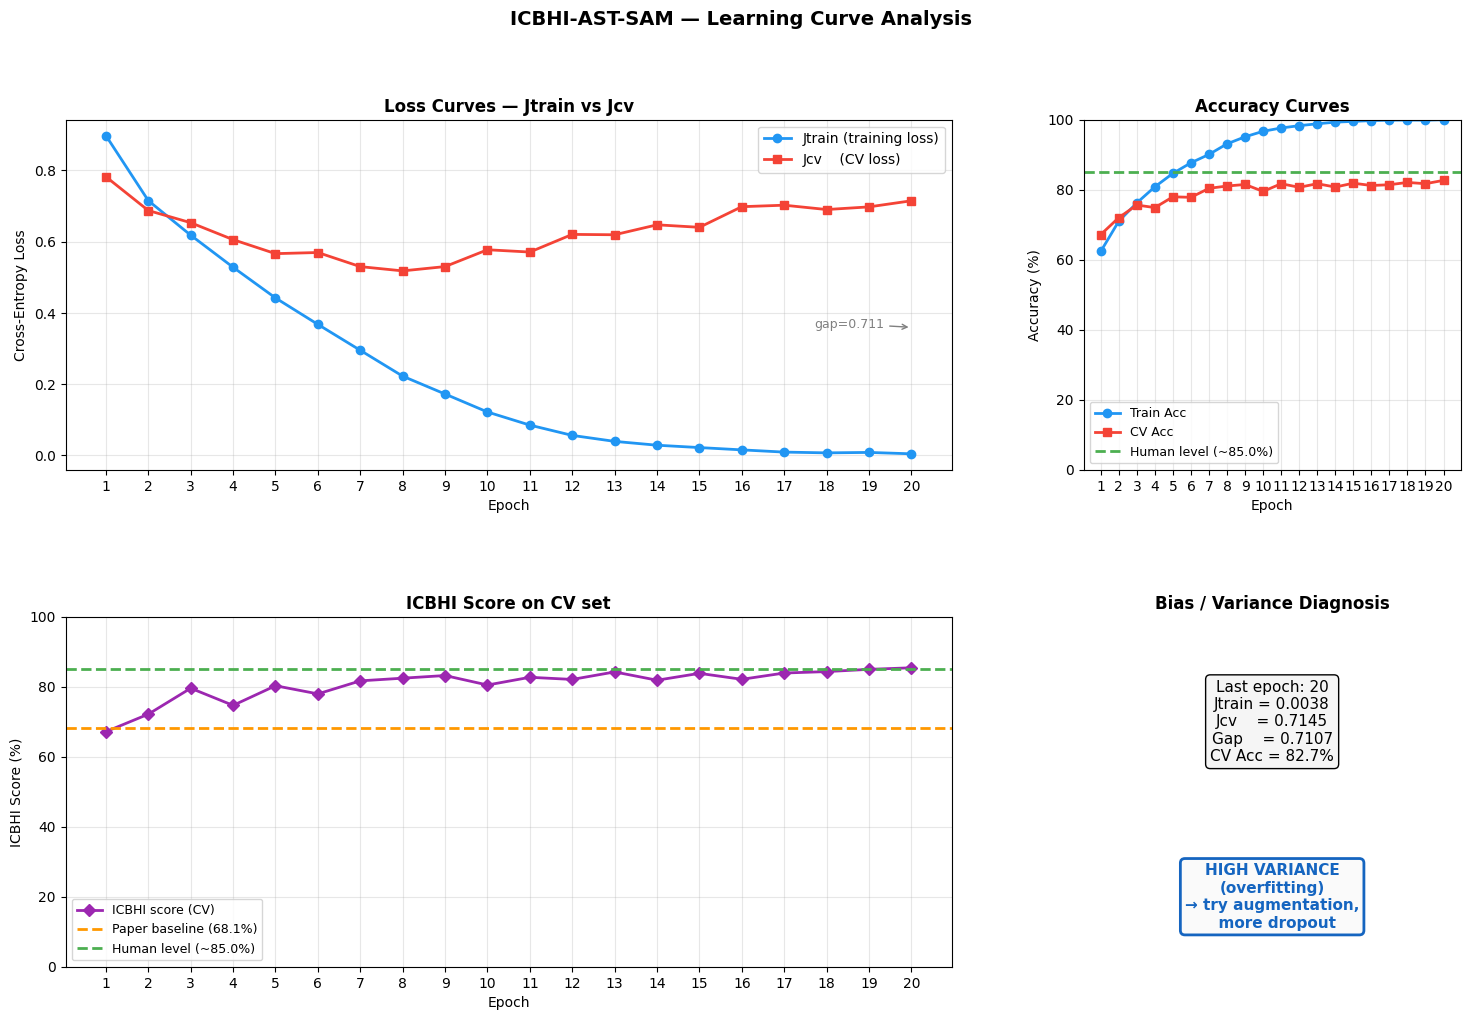

Saved: learning_curves.png


In [10]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

HISTORY_FILE = "/kaggle/working/ICBHI-AST-SAM/checkpoints/history.json"
with open(HISTORY_FILE) as f:
    h = json.load(f)

epochs     = list(range(1, len(h["train_loss"])+1))
tr_loss    = h["train_loss"]
cv_loss    = h["cv_loss"]
tr_acc     = [x*100 for x in h["train_acc"]]
cv_acc     = [x*100 for x in h["cv_acc"]]
icbhi_cv   = [x*100 for x in h["icbhi_score"]]

HUMAN_ACC   = 85.0   # approximate clinical sensitivity
PAPER_ICBHI = 68.10  # paper's reported ICBHI score

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, hspace=0.42, wspace=0.35)

# ── Plot 1: Loss curves ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(epochs, tr_loss, "o-", color="#2196F3", lw=2, label="Jtrain (training loss)")
ax1.plot(epochs, cv_loss, "s-", color="#F44336", lw=2, label="Jcv    (CV loss)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Loss Curves — Jtrain vs Jcv", fontweight="bold")
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_xticks(epochs)
if len(epochs) >= 2:
    gap = cv_loss[-1] - tr_loss[-1]
    ax1.annotate(f"gap={gap:.3f}", xy=(epochs[-1], (tr_loss[-1]+cv_loss[-1])/2),
                 xytext=(-70, 0), textcoords="offset points", fontsize=9, color="gray",
                 arrowprops=dict(arrowstyle="->", color="gray"))

# ── Plot 2: Accuracy ──────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(epochs, tr_acc, "o-", color="#2196F3", lw=2, label="Train Acc")
ax2.plot(epochs, cv_acc, "s-", color="#F44336", lw=2, label="CV Acc")
ax2.axhline(HUMAN_ACC, color="#4CAF50", lw=2, ls="--", label=f"Human level (~{HUMAN_ACC}%)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy Curves", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3); ax2.set_ylim(0,100); ax2.set_xticks(epochs)

# ── Plot 3: ICBHI score ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(epochs, icbhi_cv, "D-", color="#9C27B0", lw=2, label="ICBHI score (CV)")
ax3.axhline(PAPER_ICBHI, color="#FF9800", lw=2, ls="--", label=f"Paper baseline ({PAPER_ICBHI}%)")
ax3.axhline(HUMAN_ACC,   color="#4CAF50", lw=2, ls="--", label=f"Human level (~{HUMAN_ACC}%)")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("ICBHI Score (%)")
ax3.set_title("ICBHI Score on CV set", fontweight="bold")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3); ax3.set_ylim(0,100); ax3.set_xticks(epochs)

# ── Plot 4: Diagnosis text box ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis("off")

final_tr = tr_loss[-1]; final_cv = cv_loss[-1]; gap = final_cv - final_tr

if   final_tr > 1.0 and gap < 0.15: diag="HIGH BIAS\n(underfitting)\n→ try longer training,\n  bigger model";       col="#E65100"
elif final_tr < 1.0 and gap > 0.20: diag="HIGH VARIANCE\n(overfitting)\n→ try augmentation,\n  more dropout";       col="#1565C0"
elif final_tr > 1.0 and gap > 0.20: diag="HIGH BIAS +\nHIGH VARIANCE\n→ both problems present";                    col="#B71C1C"
else:                                diag="REASONABLE FIT\n→ focus on class imbalance\n  and threshold tuning";      col="#1B5E20"

ax4.text(0.5, 0.70,
    f"Last epoch: {len(epochs)}\n"
    f"Jtrain = {final_tr:.4f}\n"
    f"Jcv    = {final_cv:.4f}\n"
    f"Gap    = {gap:.4f}\n"
    f"CV Acc = {cv_acc[-1]:.1f}%",
    ha="center", va="center", fontsize=11,
    bbox=dict(boxstyle="round", facecolor="#F5F5F5"), transform=ax4.transAxes)
ax4.text(0.5, 0.20, diag, ha="center", va="center", fontsize=11,
    color=col, fontweight="bold",
    bbox=dict(boxstyle="round", facecolor="#FAFAFA", edgecolor=col, lw=2),
    transform=ax4.transAxes)
ax4.set_title("Bias / Variance Diagnosis", fontweight="bold")

plt.suptitle("ICBHI-AST-SAM — Learning Curve Analysis", fontsize=14, fontweight="bold")
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: learning_curves.png")


---
## Cell 9 — Test-set inference


In [11]:
import torch, numpy as np, sys, os
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.insert(0, "/kaggle/working/ICBHI-AST-SAM")
from transformers import ASTFeatureExtractor
from src.dataset import ASTDataset
from src.model   import CustomAST

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BEST_CKPT   = "/kaggle/working/ICBHI-AST-SAM/checkpoints/best_model.pth"
NPZ_PATH    = "/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz"
CKPT_DIR    = "/kaggle/working/ICBHI-AST-SAM/checkpoints"

raw    = np.load(NPZ_PATH)
X_test = raw["X_test"]; y_test = raw["y_test"]; d_test = raw["device_test"]

processor   = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
test_loader = DataLoader(
    ASTDataset(X_test, y_test, d_test, processor, train=False),
    batch_size=8, shuffle=False, num_workers=2, pin_memory=True
)

model = CustomAST(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE))
model.eval()
print(f"Best model loaded from {BEST_CKPT}")

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels, _ in tqdm(test_loader, desc="Inference", ncols=80):
        logits = model(inputs.to(DEVICE))
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

np.save(os.path.join(CKPT_DIR, "test_preds.npy"),  all_preds)
np.save(os.path.join(CKPT_DIR, "test_labels.npy"), all_labels)
np.save(os.path.join(CKPT_DIR, "test_probs.npy"),  all_probs)
print(f"Inference done on {len(all_labels)} samples. Results saved.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Best model loaded from /kaggle/working/ICBHI-AST-SAM/checkpoints/best_model.pth


Inference: 100%|██████████████████████████████| 295/295 [03:56<00:00,  1.25it/s]

Inference done on 2358 samples. Results saved.


---
## Cell 10 — Full metrics table

In [12]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, roc_auc_score)
from sklearn.preprocessing import label_binarize

CKPT_DIR    = "/kaggle/working/ICBHI-AST-SAM/checkpoints"
CLASS_NAMES = ["Normal","Crackle","Wheeze","Both"]

all_preds  = np.load(f"{CKPT_DIR}/test_preds.npy")
all_labels = np.load(f"{CKPT_DIR}/test_labels.npy")
all_probs  = np.load(f"{CKPT_DIR}/test_probs.npy")

acc   = accuracy_score(all_labels, all_preds)
prec  = precision_score(all_labels, all_preds, average="macro", zero_division=0)
rec   = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1    = f1_score(all_labels, all_preds, average="macro", zero_division=0)
y_bin = label_binarize(all_labels, classes=[0,1,2,3])
auc_m = roc_auc_score(y_bin, all_probs, average="macro", multi_class="ovr")

# Per-class specificity
spec = []
for c in range(4):
    tn = ((all_preds!=c)&(all_labels!=c)).sum()
    fp = ((all_preds==c)&(all_labels!=c)).sum()
    spec.append(tn/(tn+fp+1e-9))

icbhi = (rec + np.mean(spec)) / 2 * 100

print("="*68)
print("FULL TEST-SET METRICS")
print("="*68)
print(f"{'Metric':<38} {'Ours':>10}  {'Paper':>8}")
print("-"*60)
print(f"{'Accuracy':<38} {acc*100:>9.2f}%  {'N/A':>8}")
print(f"{'Precision (macro)':<38} {prec*100:>9.2f}%  {'N/A':>8}")
print(f"{'Recall / Sensitivity (macro)':<38} {rec*100:>9.2f}%  {'68.31%':>8}")
print(f"{'Specificity (macro)':<38} {np.mean(spec)*100:>9.2f}%  {'67.89%':>8}")
print(f"{'F1-score (macro)':<38} {f1*100:>9.2f}%  {'N/A':>8}")
print(f"{'AUC-ROC (macro OvR)':<38} {auc_m:>9.4f}   {'N/A':>8}")
print(f"{'ICBHI Score (Se+Sp)/2':<38} {icbhi:>9.2f}%  {'68.10%':>8}")
print("-"*60)

rec_pc  = recall_score(all_labels, all_preds, average=None, zero_division=0)
prec_pc = precision_score(all_labels, all_preds, average=None, zero_division=0)
f1_pc   = f1_score(all_labels, all_preds, average=None, zero_division=0)

print(f"\n{'Class':<10} {'Prec':>8} {'Recall':>8} {'F1':>8} {'Spec':>8} {'AUC':>8}")
print("-"*55)
for i, name in enumerate(CLASS_NAMES):
    auc_i = roc_auc_score(y_bin[:,i], all_probs[:,i])
    print(f"{name:<10} {prec_pc[i]*100:>7.2f}% {rec_pc[i]*100:>7.2f}% "
          f"{f1_pc[i]*100:>7.2f}% {spec[i]*100:>7.2f}% {auc_i:>8.4f}")

print("\n" + "="*68)
print("SKLEARN CLASSIFICATION REPORT")
print("="*68)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))


FULL TEST-SET METRICS
Metric                                       Ours     Paper
------------------------------------------------------------
Accuracy                                   62.77%       N/A
Precision (macro)                          49.18%       N/A
Recall / Sensitivity (macro)               45.22%    68.31%
Specificity (macro)                        83.18%    67.89%
F1-score (macro)                           45.40%       N/A
AUC-ROC (macro OvR)                       0.7879        N/A
ICBHI Score (Se+Sp)/2                      64.20%    68.10%
------------------------------------------------------------

Class          Prec   Recall       F1     Spec      AUC
-------------------------------------------------------
Normal       70.06%   81.57%   75.38%   54.13%   0.7527
Crackle      54.33%   41.83%   47.27%   88.00%   0.7638
Wheeze       42.31%   48.59%   45.23%   92.18%   0.8136
Both         30.00%    8.88%   13.70%   98.40%   0.8213

SKLEARN CLASSIFICATION REPORT
        

---
## Cell 11 — Confusion matrices + ROC curves

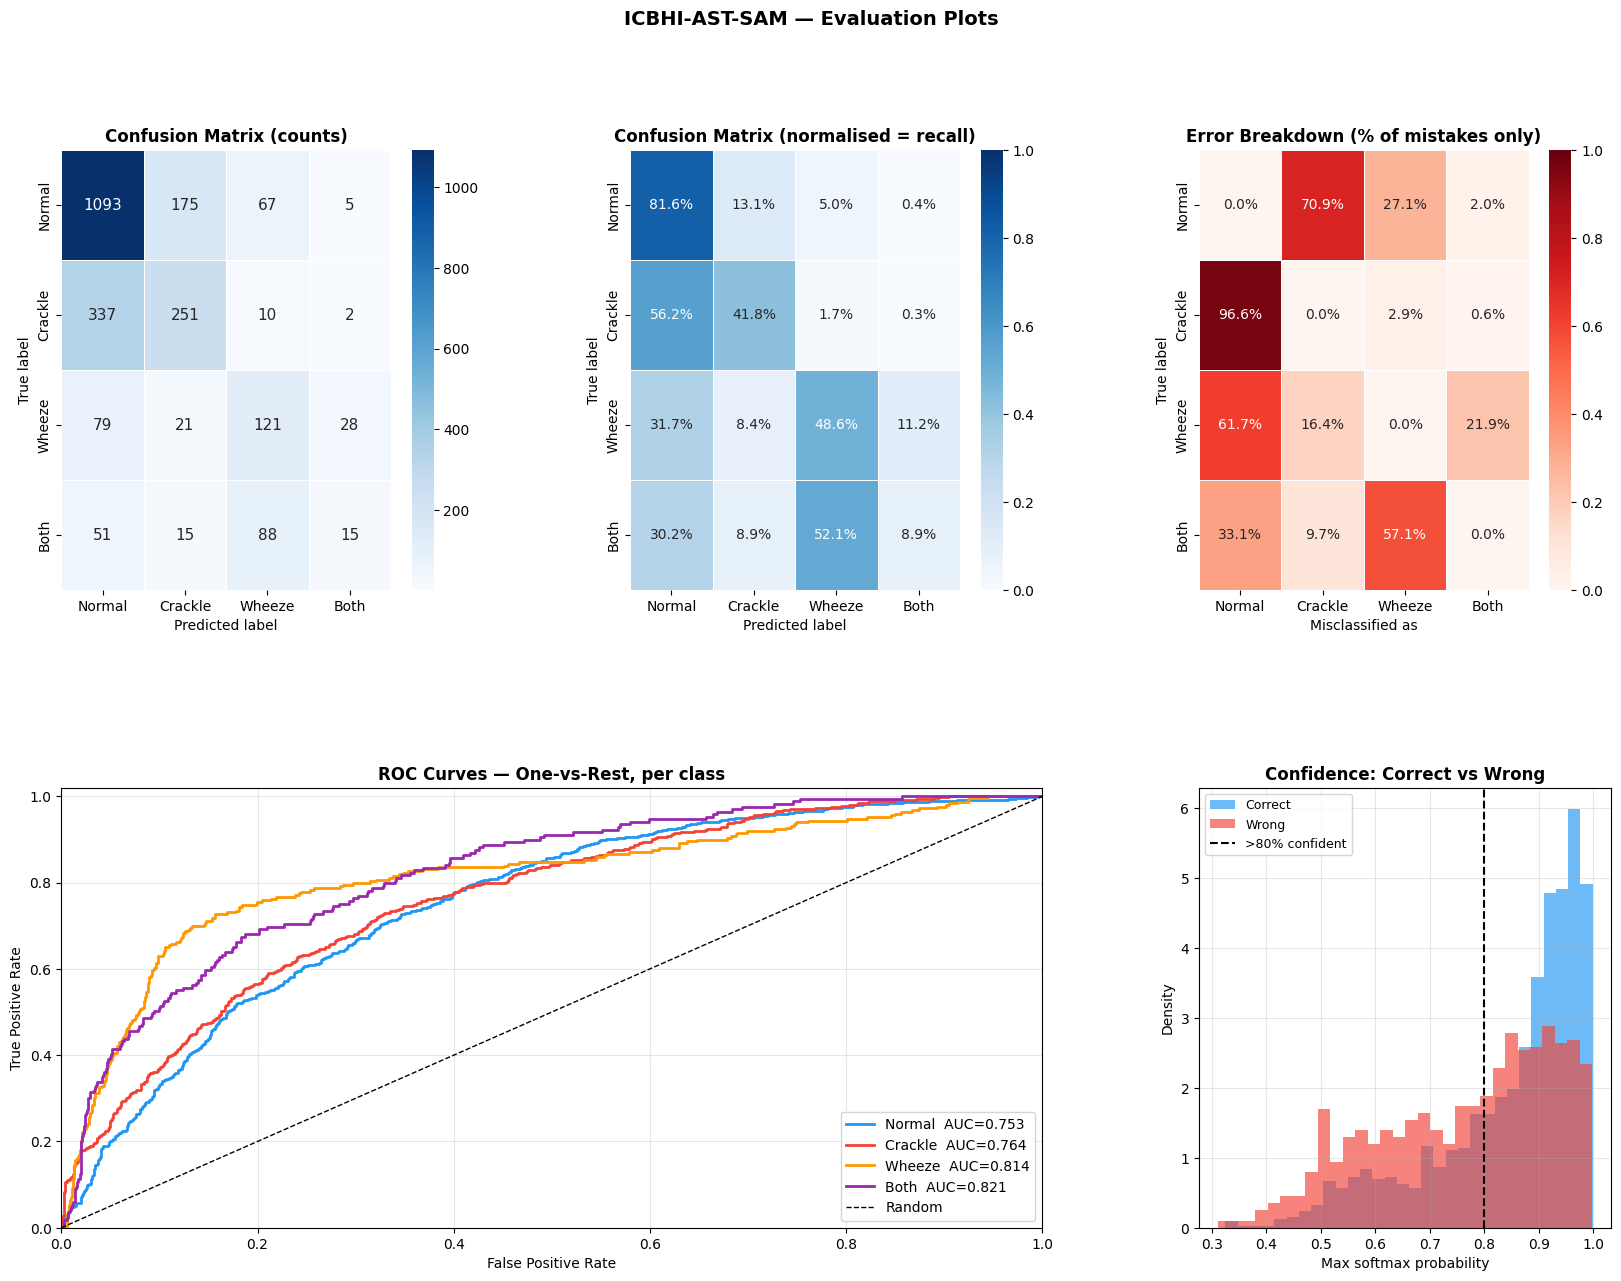

Saved: evaluation.png


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

CKPT_DIR    = "/kaggle/working/ICBHI-AST-SAM/checkpoints"
CLASS_NAMES = ["Normal","Crackle","Wheeze","Both"]
COLORS      = ["#2196F3","#F44336","#FF9800","#9C27B0"]

all_preds  = np.load(f"{CKPT_DIR}/test_preds.npy")
all_labels = np.load(f"{CKPT_DIR}/test_labels.npy")
all_probs  = np.load(f"{CKPT_DIR}/test_probs.npy")
y_bin      = label_binarize(all_labels, classes=[0,1,2,3])
cm         = confusion_matrix(all_labels, all_preds)

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)

# (A) Raw confusion matrix
ax1 = fig.add_subplot(gs[0,0])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax1, linewidths=0.5, annot_kws={"size":11})
ax1.set_title("Confusion Matrix (counts)", fontweight="bold")
ax1.set_ylabel("True label"); ax1.set_xlabel("Predicted label")

# (B) Normalised confusion matrix — recall on the diagonal
ax2     = fig.add_subplot(gs[0,1])
cm_norm = cm.astype("float") / cm.sum(axis=1)[:,np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax2, linewidths=0.5, vmin=0, vmax=1, annot_kws={"size":10})
ax2.set_title("Confusion Matrix (normalised = recall)", fontweight="bold")
ax2.set_ylabel("True label"); ax2.set_xlabel("Predicted label")

# (C) Error-only matrix — of all mistakes, where does each class end up?
ax3 = fig.add_subplot(gs[0,2])
err = cm.astype("float"); np.fill_diagonal(err, 0)
rs  = err.sum(axis=1, keepdims=True); rs[rs==0] = 1; err /= rs
sns.heatmap(err, annot=True, fmt=".1%", cmap="Reds",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax3, linewidths=0.5, vmin=0, vmax=1, annot_kws={"size":10})
ax3.set_title("Error Breakdown (% of mistakes only)", fontweight="bold")
ax3.set_ylabel("True label"); ax3.set_xlabel("Misclassified as")

# (D) ROC curves (One-vs-Rest)
ax4 = fig.add_subplot(gs[1,:2])
for i, (name, col) in enumerate(zip(CLASS_NAMES, COLORS)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], all_probs[:,i])
    ax4.plot(fpr, tpr, color=col, lw=2, label=f"{name}  AUC={auc(fpr,tpr):.3f}")
ax4.plot([0,1],[0,1],"k--",lw=1,label="Random")
ax4.set_xlabel("False Positive Rate"); ax4.set_ylabel("True Positive Rate")
ax4.set_title("ROC Curves — One-vs-Rest, per class", fontweight="bold")
ax4.legend(fontsize=10, loc="lower right"); ax4.grid(alpha=0.3)
ax4.set_xlim([0,1]); ax4.set_ylim([0,1.02])

# (E) Model confidence: correct vs wrong predictions
ax5  = fig.add_subplot(gs[1,2])
conf = all_probs.max(axis=1)
ok   = all_preds == all_labels
ax5.hist(conf[ok],  bins=30, alpha=0.65, color="#2196F3", label="Correct", density=True)
ax5.hist(conf[~ok], bins=30, alpha=0.65, color="#F44336", label="Wrong",   density=True)
ax5.axvline(0.8, color="black", ls="--", lw=1.5, label=">80% confident")
ax5.set_xlabel("Max softmax probability"); ax5.set_ylabel("Density")
ax5.set_title("Confidence: Correct vs Wrong", fontweight="bold")
ax5.legend(fontsize=9); ax5.grid(alpha=0.3)

plt.suptitle("ICBHI-AST-SAM — Evaluation Plots", fontsize=14, fontweight="bold")
plt.savefig("evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: evaluation.png")


---
## Cell 12 — Deep error analysis

This cell answers three questions:
1. **Which class fails most?** — per-class error rate
2. **What does each class get confused with?** — most common mistake per true class
3. **Are the failures confident or uncertain?** — high-confidence wrong predictions are the most dangerous in a medical context
4. **Does device matter?** — error rate broken down by recording equipment

These findings directly tell us which improvement to prioritise.

ERROR ANALYSIS — TEST SET

Total samples : 2358
Correct       : 1480  (62.8%)
Errors        : 878   (37.2%)

── Per-class error rate ────────────────────────────────
  Normal   :  247/1340  (18.4%)  → mostly confused with: Crackle (175x)
  Crackle  :  349/600   (58.2%)  → mostly confused with: Normal (337x)
  Wheeze   :  128/249   (51.4%)  → mostly confused with: Normal (79x)
  Both     :  154/169   (91.1%)  → mostly confused with: Wheeze (88x)

── Confidence analysis ────────────────────────────────
  Avg confidence when CORRECT : 84.7%
  Avg confidence when WRONG   : 76.6%
  High-conf (>80%) AND wrong  : 442 cases  ← dangerous

── Per-device error rate ───────────────────────────────
  AKGC417L    : 1234 samples  error rate 44.9%
  LittC2SE    :  143 samples  error rate 26.6%
  Litt3200    :  174 samples  error rate 38.5%
  Meditron    :  807 samples  error rate 27.1%


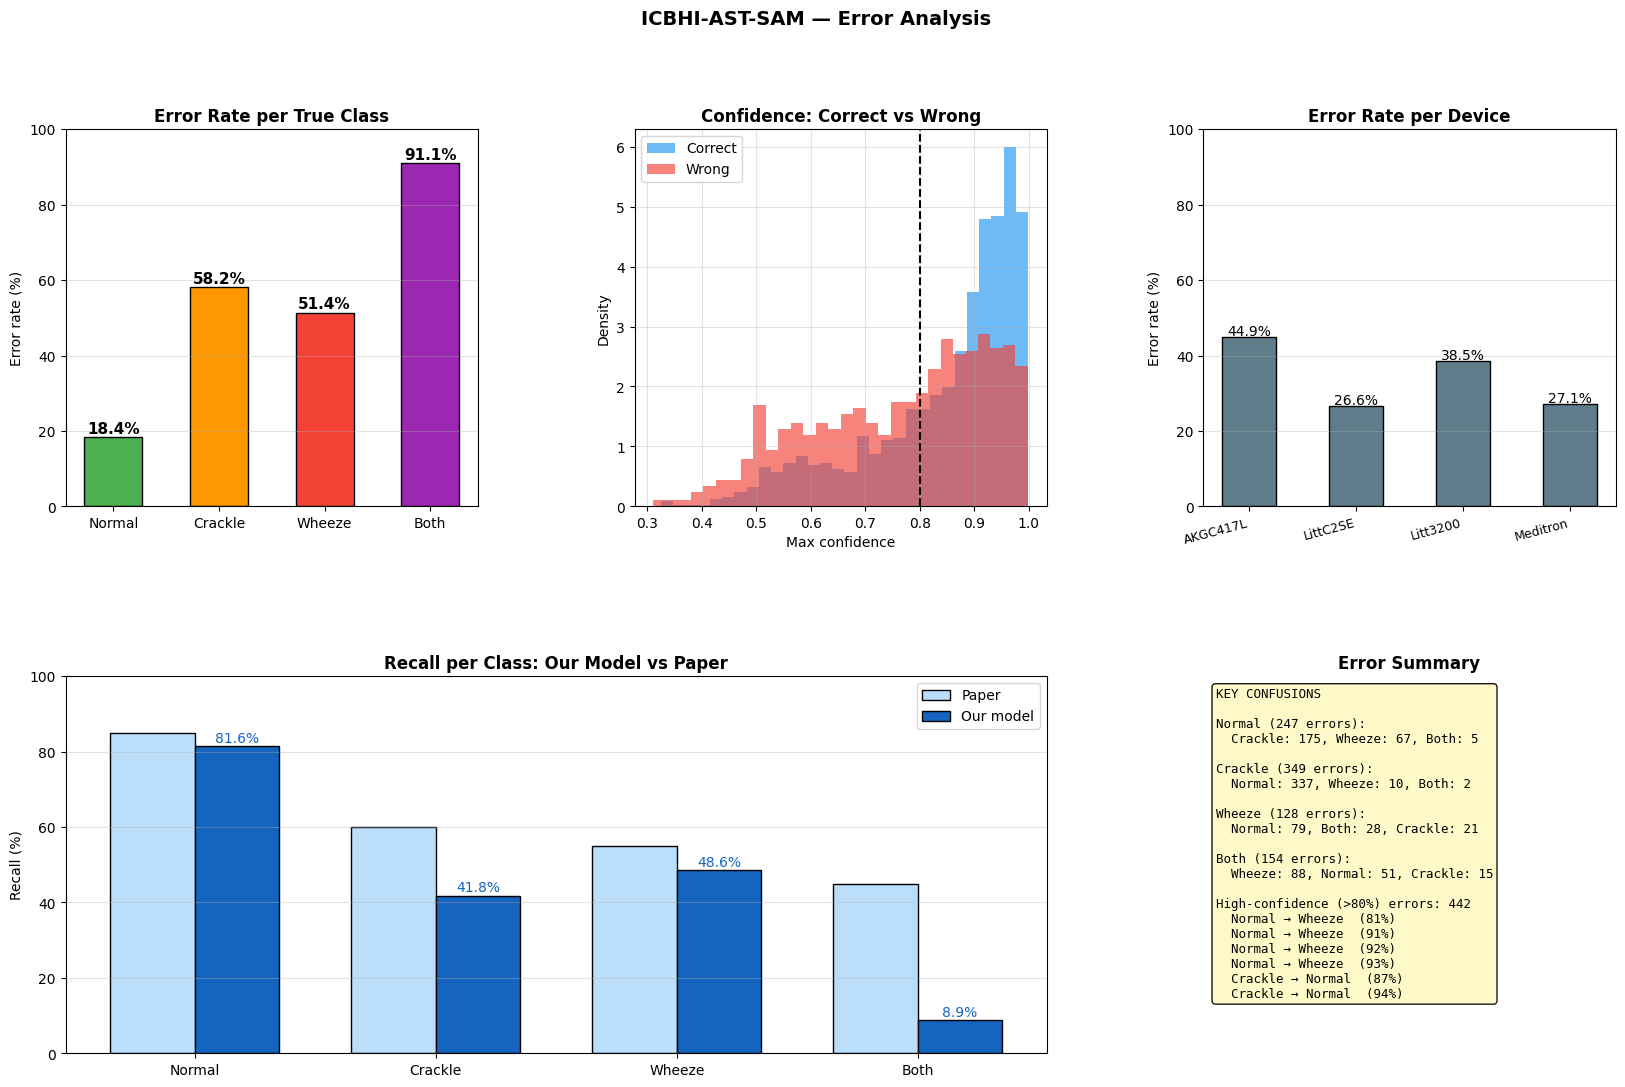

Saved: error_analysis.png


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter

CKPT_DIR     = "/kaggle/working/ICBHI-AST-SAM/checkpoints"
NPZ_PATH     = "/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz"
CLASS_NAMES  = ["Normal","Crackle","Wheeze","Both"]
DEVICE_NAMES = ["AKGC417L","LittC2SE","Litt3200","Meditron"]
COLORS       = ["#4CAF50","#FF9800","#F44336","#9C27B0"]

all_preds  = np.load(f"{CKPT_DIR}/test_preds.npy")
all_labels = np.load(f"{CKPT_DIR}/test_labels.npy")
all_probs  = np.load(f"{CKPT_DIR}/test_probs.npy")
d_test     = np.load(NPZ_PATH)["device_test"]

errors   = all_preds != all_labels
correct  = ~errors
max_conf = all_probs.max(axis=1)
high_conf_wrong = errors & (max_conf > 0.80)

print("="*65)
print("ERROR ANALYSIS — TEST SET")
print("="*65)
print(f"\nTotal samples : {len(all_labels)}")
print(f"Correct       : {correct.sum()}  ({correct.mean()*100:.1f}%)")
print(f"Errors        : {errors.sum()}   ({errors.mean()*100:.1f}%)")

print("\n── Per-class error rate ────────────────────────────────")
for i, name in enumerate(CLASS_NAMES):
    mask   = all_labels == i
    n_err  = (all_preds[mask]!=i).sum()
    n_tot  = mask.sum()
    rate   = n_err/n_tot*100
    mc_idx = Counter(all_preds[mask & errors]).most_common(1)
    mc_str = f"→ mostly confused with: {CLASS_NAMES[mc_idx[0][0]]} ({mc_idx[0][1]}x)" if mc_idx else ""
    print(f"  {name:<9}: {n_err:>4}/{n_tot:<5} ({rate:.1f}%)  {mc_str}")

print("\n── Confidence analysis ────────────────────────────────")
print(f"  Avg confidence when CORRECT : {max_conf[correct].mean()*100:.1f}%")
print(f"  Avg confidence when WRONG   : {max_conf[errors].mean()*100:.1f}%")
print(f"  High-conf (>80%) AND wrong  : {high_conf_wrong.sum()} cases  ← dangerous")

print("\n── Per-device error rate ───────────────────────────────")
for d, dname in enumerate(DEVICE_NAMES):
    m = d_test == d
    if m.sum() == 0: continue
    er = (all_preds[m] != all_labels[m]).mean()*100
    print(f"  {dname:<12}: {m.sum():>4} samples  error rate {er:.1f}%")

# ── Figures ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)

# (A) Error rate per true class
ax1 = fig.add_subplot(gs[0,0])
err_rates = [(all_preds[all_labels==i]!=i).mean()*100 for i in range(4)]
bars = ax1.bar(CLASS_NAMES, err_rates, color=COLORS, edgecolor="black", width=0.55)
for b, v in zip(bars, err_rates):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{v:.1f}%",
             ha="center", fontsize=11, fontweight="bold")
ax1.set_ylabel("Error rate (%)"); ax1.set_ylim(0,100)
ax1.set_title("Error Rate per True Class", fontweight="bold"); ax1.grid(axis="y",alpha=0.35)

# (B) Confidence distribution: correct vs wrong
ax2 = fig.add_subplot(gs[0,1])
ax2.hist(max_conf[correct], bins=30, alpha=0.65, color="#2196F3", label="Correct", density=True)
ax2.hist(max_conf[errors],  bins=30, alpha=0.65, color="#F44336", label="Wrong",   density=True)
ax2.axvline(0.8, color="black", ls="--", lw=1.5)
ax2.set_xlabel("Max confidence"); ax2.set_ylabel("Density")
ax2.set_title("Confidence: Correct vs Wrong", fontweight="bold")
ax2.legend(); ax2.grid(alpha=0.35)

# (C) Per-device error rate
ax3 = fig.add_subplot(gs[0,2])
d_labs, d_errs = [], []
for d, dname in enumerate(DEVICE_NAMES):
    m = d_test == d
    if m.sum() == 0: continue
    d_labs.append(dname); d_errs.append((all_preds[m]!=all_labels[m]).mean()*100)
bars = ax3.bar(d_labs, d_errs, color="#607D8B", edgecolor="black", width=0.5)
for b, v in zip(bars, d_errs):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{v:.1f}%", ha="center")
ax3.set_ylabel("Error rate (%)"); ax3.set_ylim(0,100)
ax3.set_title("Error Rate per Device", fontweight="bold"); ax3.grid(axis="y",alpha=0.35)
plt.setp(ax3.get_xticklabels(), rotation=15, ha="right", fontsize=9)

# (D) Recall comparison: our model vs paper
ax4 = fig.add_subplot(gs[1,:2])
our_rec   = [(all_preds[all_labels==i]==i).mean()*100 for i in range(4)]
paper_rec = [85.0, 60.0, 55.0, 45.0]  # approx from paper Table 2
x = np.arange(4); w = 0.35
ax4.bar(x-w/2, paper_rec, w, label="Paper",      color="#BBDEFB", edgecolor="black")
ax4.bar(x+w/2, our_rec,   w, label="Our model",  color="#1565C0", edgecolor="black")
for i, v in enumerate(our_rec):
    ax4.text(x[i]+w/2, v+1, f"{v:.1f}%", ha="center", fontsize=10, color="#1565C0")
ax4.set_xticks(x); ax4.set_xticklabels(CLASS_NAMES); ax4.set_ylabel("Recall (%)")
ax4.set_title("Recall per Class: Our Model vs Paper", fontweight="bold")
ax4.legend(); ax4.set_ylim(0,100); ax4.grid(axis="y",alpha=0.35)

# (E) Text summary of key confusions + high-confidence errors
ax5 = fig.add_subplot(gs[1,2])
ax5.axis("off")

lines = ["KEY CONFUSIONS\n"]
for i, name in enumerate(CLASS_NAMES):
    m = (all_labels==i) & errors
    if m.sum()==0: continue
    confused = Counter(all_preds[m])
    detail   = ", ".join(f"{CLASS_NAMES[k]}: {v}" for k,v in confused.most_common())
    lines.append(f"{name} ({m.sum()} errors):")
    lines.append(f"  {detail}\n")

hcw = np.where(high_conf_wrong)[0]
lines.append(f"High-confidence (>80%) errors: {len(hcw)}")
for idx in hcw[:6]:
    lines.append(f"  {CLASS_NAMES[all_labels[idx]]} → {CLASS_NAMES[all_preds[idx]]}"
                 f"  ({max_conf[idx]*100:.0f}%)")

ax5.text(0.03, 0.97, "\n".join(lines), ha="left", va="top", fontsize=9,
         family="monospace",
         bbox=dict(boxstyle="round", facecolor="#FFF9C4", alpha=0.9),
         transform=ax5.transAxes)
ax5.set_title("Error Summary", fontweight="bold")

plt.suptitle("ICBHI-AST-SAM — Error Analysis", fontsize=14, fontweight="bold")
plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: error_analysis.png")
